In [30]:
import sys
from pathlib import Path

# __file__ is not defined in notebooks — find project root by locating the analytics package
_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'analytics').exists())
sys.path.insert(0, str(_root))

import os
import pandas as pd
import numpy as np
import duckdb

import matplotlib.pyplot as plt
import seaborn as sns
import matplotsoccer as mpl

from analytics.constants import LEAGUE_NAME_DICT, POSITION_MAPPING, POSITION_MAPPING_SIDES
from analytics.player_pipeline import build_player_game_df, build_player_season_df

import streamlit as st

pd.set_option('display.max_columns', 22)
pd.set_option('display.width', 500)

# =========================================
# === Option A: Load from parquet files ===
# =========================================

df_players = pd.read_parquet('data/df_players-2526.parquet')
df_player_matches = pd.read_parquet('data/df_player_matches-2526.parquet')


# ===========================================
# === Option B: Load from DuckDB database ===
# ===========================================

#DB_PATH = '/home/max/soccerdata/data/WhoScored/duckdb/football.duckdb'
#con = duckdb.connect(DB_PATH, read_only=True)

#def query_df(sql: str) -> pd.DataFrame:
#    return con.execute(sql).df()

# Load per-game data from player_match_vaep (pre-aggregated — fast)
#df_player_matches_raw = build_player_game_df(con)

# Rename VAEP columns to legacy names expected by downstream cells
#df_p_per_match = df_player_matches_raw.rename(columns={
#    'vaep_total': 'total_vaep_value',
#    'off_total':  'total_offensive_value',
#    'def_total':  'total_defensive_value',
#})

# Game-level MultiIndex DataFrame (includes synthetic categories already)
#df_player_matches = df_p_per_match.set_index(['league', 'season', 'team', 'player_name'])

#df = build_player_season_df(con, seasons=['2526'], include_market_value=True)


In [35]:
len(df_players.reset_index().league.unique().tolist())

18

In [39]:
df_player_matches.reset_index()[['league', 'game_id']].drop_duplicates().groupby('league').count().sort_values('game_id', ascending=False)

,game_id
league,
USA-Major League Soccer,531
BRA-Serie A,380
ENG-Championship,342
ENG-League One,316
ENG-Premier League,229
ITA-Serie A,218
ESP-La Liga,207
NED-Eredivisie,178
BEL-Pro League,176


## FIND PLAYERS WITH CRITERIA

In [16]:
POSITION = "CM"
MINUTES_MIN = 180
MINUTES_MAX = np.inf
MARKETVAL_MIO_MIN = 0
MARKETVAL_MIO_MAX = np.inf

LEAGUES = df_players.index.get_level_values('league').unique().tolist()
SEASONS = '2526'  #df_players.index.get_level_values('season').unique().tolist()

TYPE_NAMES = 'total_nogoals'

LS_COLS = ['vaep_total', 'vaep90', 'off_total', 'def_total', 'off90', 'vaep_stability', 'position', 'main_position', 'minutes_played', 'market_value_eur']

SORT_BY = 'vaep_total'

ROUND_BY = 2
TOP_N = 30

idx = pd.IndexSlice

In [24]:
df_filtered = df_players[
    df_players['position'] == POSITION
].loc[idx[
    LEAGUES, SEASONS, :,  :],
      LS_COLS
      ].sort_values(
          by=SORT_BY, ascending=False).reset_index()#.head(TOP_N).round(ROUND_BY).reset_index()

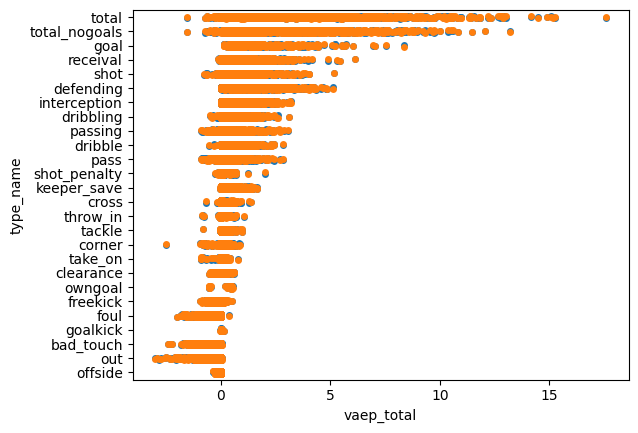

In [29]:
plot = sns.stripplot(x='vaep_total', y='type_name', data=df_filtered)
plt.show()

In [28]:
plot

<Axes: xlabel='vaep_total', ylabel='type_name'>